In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

In [ ]:
municipios = pd.read_excel('/content/pibMunicipios.xlsx')

In [ ]:
municipios.columns = ['ano', 'cd_grande_rg', 'nm_grande_rg',
'cd_uf', 'sg_uf', 'nm_uf',
'cd_municipio', 'nm_municipio', 'regiao_metropolitana',
'cd_mesorregiao', 'nm_mesorregiao', 'cd_microregiao', 'nm_microregiao',
'cd_rg_imediata', 'nm_rg_imediata', 'municipio_rg_imediata',
'cd_rg_intermediaria', 'nm_rg_intermediaria', 'municipio_rg_intermediaria',
'cd_concentracao_urbana', 'nm_concentracao_urbana', 'tipo_concentracao_urbana',
'cd_arranjo_populacional', 'nm_arranjo_populacional', 'hierarquia_urbana',
'hierarquia_urbana_cat', 'cd_rg_rural', 'nm_rg_rural',
'rg_rural_nucleo', 'amazonia_legal', 'semiarido', 'cidade_regiao_sp',
'vab_agropecuaria_mil', 'vab_industria_mil', 'vab_servicos_mil',
'vab_adm_publica_mil', 'vab_total_mil', 'taxa_liq_produtos_mil',
'pib_mil', 'pib_per_capita_r$1',
'ativ_maior_vab', 'ativ_segundo_maior_vab', 'ativ_terceiro_maior_vab']

In [ ]:
municipios.head()

,ano,cd_grande_rg,nm_grande_rg,cd_uf,sg_uf,nm_uf,cd_municipio,nm_municipio,regiao_metropolitana,cd_mesorregiao,...,vab_servicos_mil,vab_adm_publica_mil,vab_total_mil,taxa_liq_produtos_mil,pib_mil,pib_per_capita_r$1,ativ_maior_vab,ativ_segundo_maior_vab,ativ_terceiro_maior_vab,pib_mil_zscore
0,2010,1,Norte,11,RO,Rondônia,1100015,Alta Floresta D'Oeste,NaN,1102,...,62496.185,93244.656,241119.767,20957.111,262076.878,10731.18,"Administração, defesa, educação e saúde públic...","Pecuária, inclusive apoio à pecuária",Demais serviços,-0.077515
1,2010,1,Norte,11,RO,Rondônia,1100023,Ariquemes,NaN,1102,...,494946.267,343867.731,1199664.227,165029.553,1364693.780,15103.86,"Administração, defesa, educação e saúde públic...",Demais serviços,Comércio e reparação de veículos automotores e...,0.023502
2,2010,1,Norte,11,RO,Rondônia,1100031,Cabixi,NaN,1102,...,12677.210,25170.235,65400.772,4210.342,69611.114,11033.62,"Administração, defesa, educação e saúde públic...","Pecuária, inclusive apoio à pecuária",Demais serviços,-0.095148
3,2010,1,Norte,11,RO,Rondônia,1100049,Cacoal,NaN,1102,...,465447.325,298454.309,1041212.374,145281.717,1186494.091,15095.15,"Administração, defesa, educação e saúde públic...",Demais serviços,Comércio e reparação de veículos automotores e...,0.007176
4,2010,1,Norte,11,RO,Rondônia,1100056,Cerejeiras,NaN,1102,...,80724.991,63018.270,192454.160,29567.029,222021.189,13037.06,"Administração, defesa, educação e saúde públic...",Demais serviços,Comércio e reparação de veículos automotores e...,-0.081185


In [ ]:
municipios_por_ano = municipios.groupby('ano')

In [ ]:
municipios['pib_mil_zscore'] = zscore(municipios['pib_mil'])

In [ ]:
pib_por_ano_regiao = municipios.groupby(['ano', 'Regiao'])['pib_mil_zscore'].mean().reset_index()

KeyError: 'Regiao'

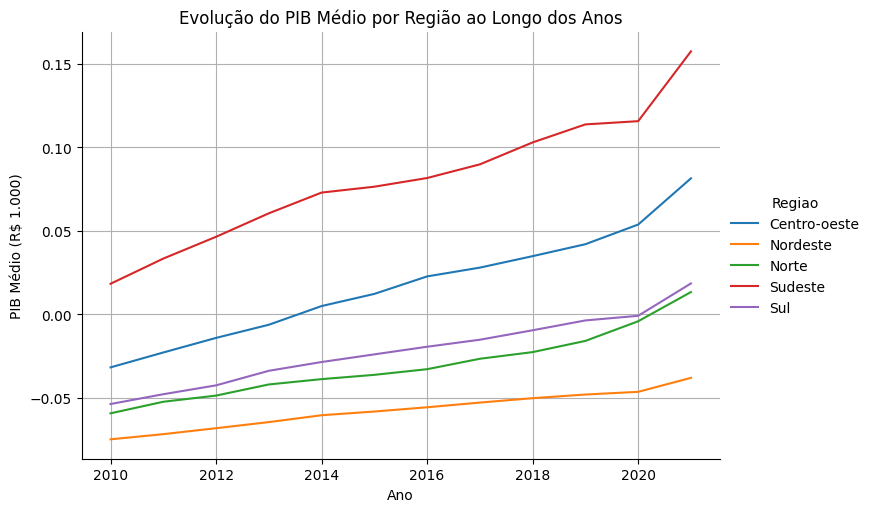

In [ ]:
sns.relplot(data=pib_por_ano_regiao, x="Ano", y="pib_mil_zscore", hue="Regiao", kind="line", aspect=1.5)
plt.title('Evolução do PIB Médio por Região ao Longo dos Anos')
plt.xlabel('Ano')
plt.ylabel('PIB Médio (R$ 1.000)')
plt.grid(True)
plt.show()

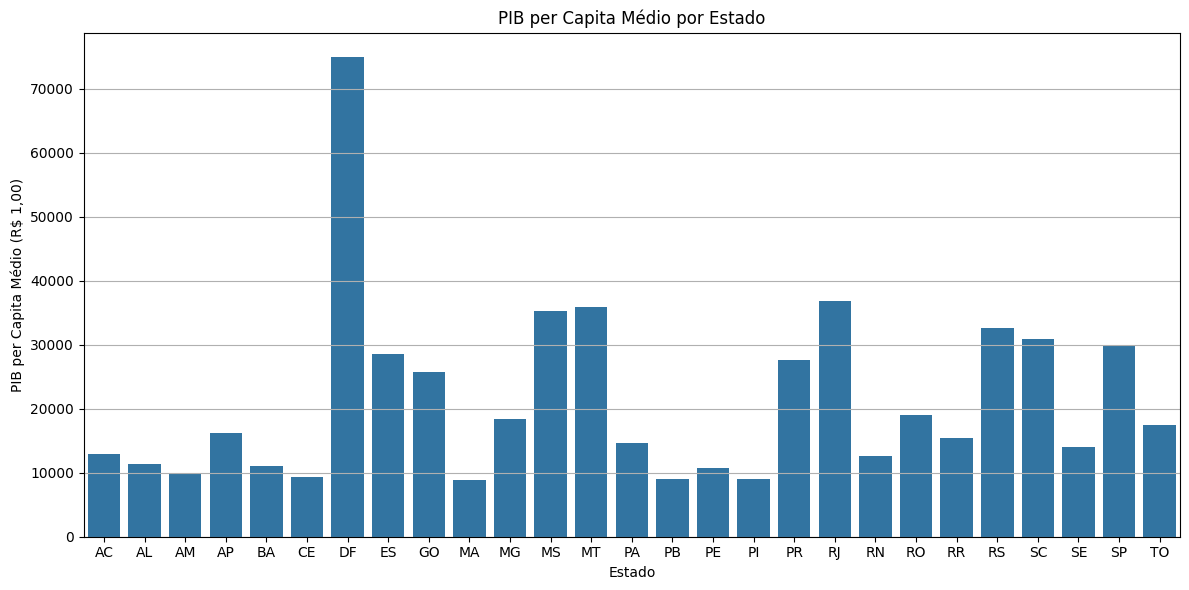

In [ ]:
pib_per_capita_por_estado = municipios.groupby('sg_uf')['pib_per_capita_r$1'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(x='sg_uf', y='pib_per_capita_r$1', data=pib_per_capita_por_estado)
plt.title('PIB per Capita Médio por Estado')
plt.xlabel('Estado')
plt.ylabel('PIB per Capita Médio (R$ 1,00)')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

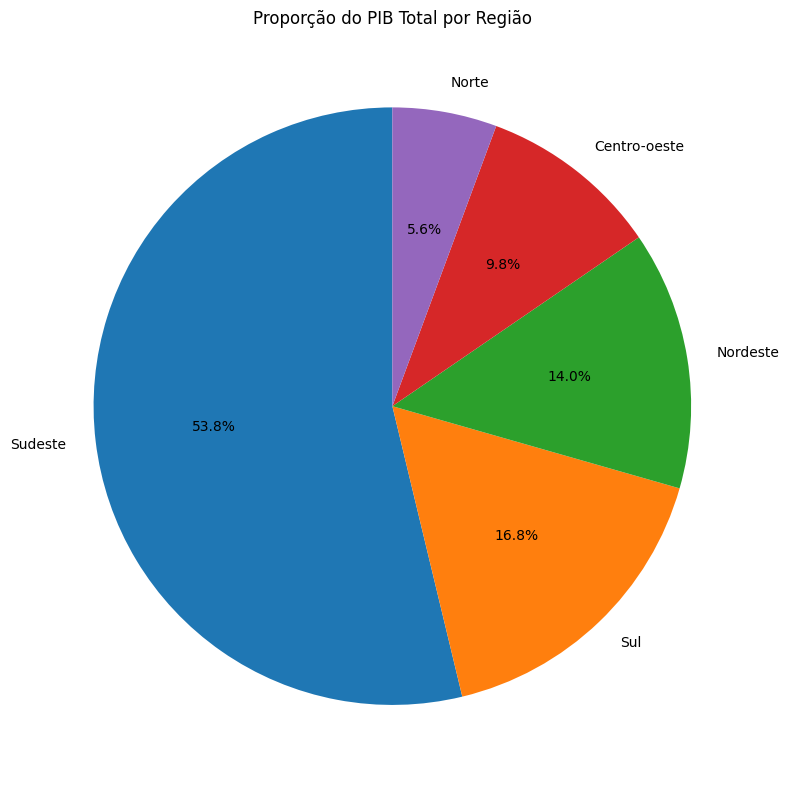

In [ ]:
tot_pib = municipios['pib_mil'].sum()

# Calculate the sum of PIB for each region
pib_por_regiao = municipios.groupby('nm_grande_rg')['pib_mil'].sum().reset_index()

pib_por_regiao['proporcao_pib_total'] = pib_por_regiao['pib_mil'] / tot_pib

pib_por_regiao = pib_por_regiao.sort_values(by='proporcao_pib_total', ascending=False)

plt.figure(figsize=(8, 8))
plt.pie(pib_por_regiao['proporcao_pib_total'], labels=pib_por_regiao['nm_grande_rg'], autopct='%1.1f%%', startangle=90)
plt.title('Proporção do PIB Total por Região')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

In [ ]:
atividade_por_regiao = municipios.groupby('nm_grande_rg')[['vab_agropecuaria_mil', 'vab_industria_mil', 'vab_servicos_mil', 'vab_adm_publica_mil']].mean().reset_index()
display(atividade_por_regiao)

,nm_grande_rg,vab_agropecuaria_mil,vab_industria_mil,vab_servicos_mil,vab_adm_publica_mil
0,Centro-oeste,134848.338267,175130.624992,5.294360e+05,305639.250410
1,Nordeste,29933.492870,84204.820298,2.031902e+05,104951.093064
2,Norte,69795.020977,198999.943800,2.520028e+05,168038.668164
3,Sudeste,40633.163016,417265.159288,1.006577e+06,217708.823905
4,Sul,67622.285488,193404.808031,3.838980e+05,102511.931355


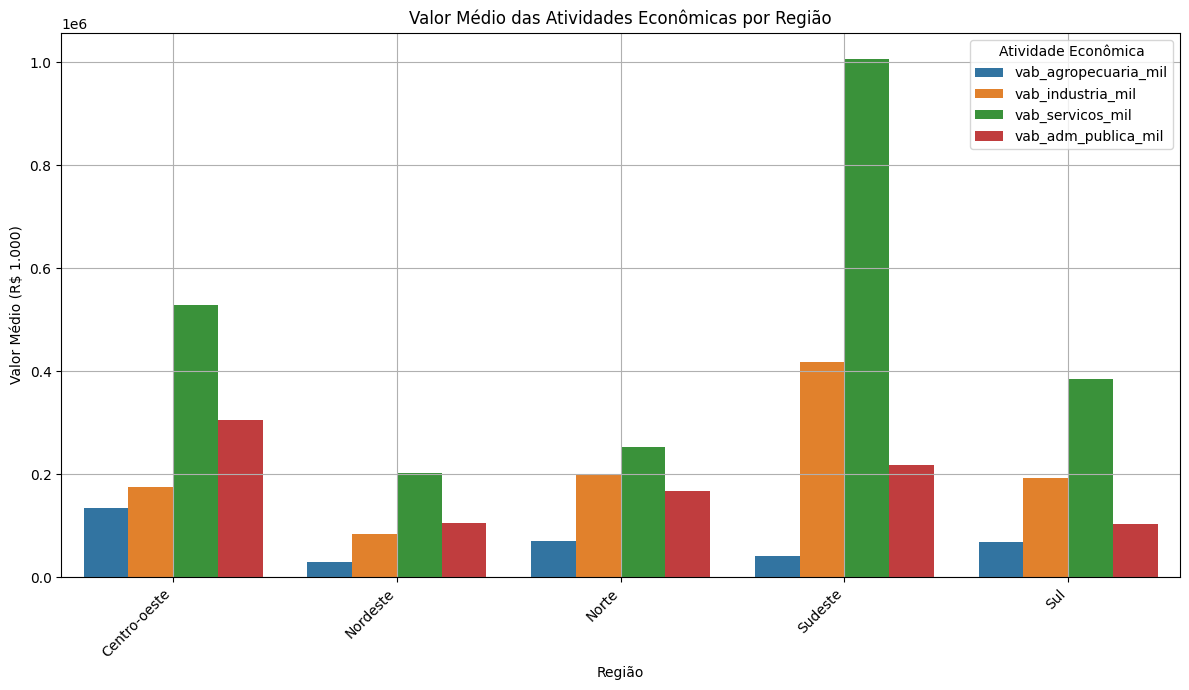

In [ ]:
atividade_por_regiao_melted = atividade_por_regiao.melt(id_vars='nm_grande_rg', var_name='Atividade Econômica', value_name='Valor Médio (R$ 1.000)')

plt.figure(figsize=(12, 7))
sns.barplot(x='nm_grande_rg', y='Valor Médio (R$ 1.000)', hue='Atividade Econômica', data=atividade_por_regiao_melted)
plt.title('Valor Médio das Atividades Econômicas por Região')
plt.xlabel('Região')
plt.ylabel('Valor Médio (R$ 1.000)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(True)
plt.show()

In [ ]:
pib_medio_por_regiao = municipios.groupby('nm_grande_rg')['pib_mil'].mean().reset_index()
display(pib_medio_por_regiao)

,nm_grande_rg,pib_mil
0,Centro-oeste,1.294442e+06
1,Nordeste,4.814321e+05
2,Norte,7.752242e+05
3,Sudeste,1.988989e+06
4,Sul,8.711917e+05


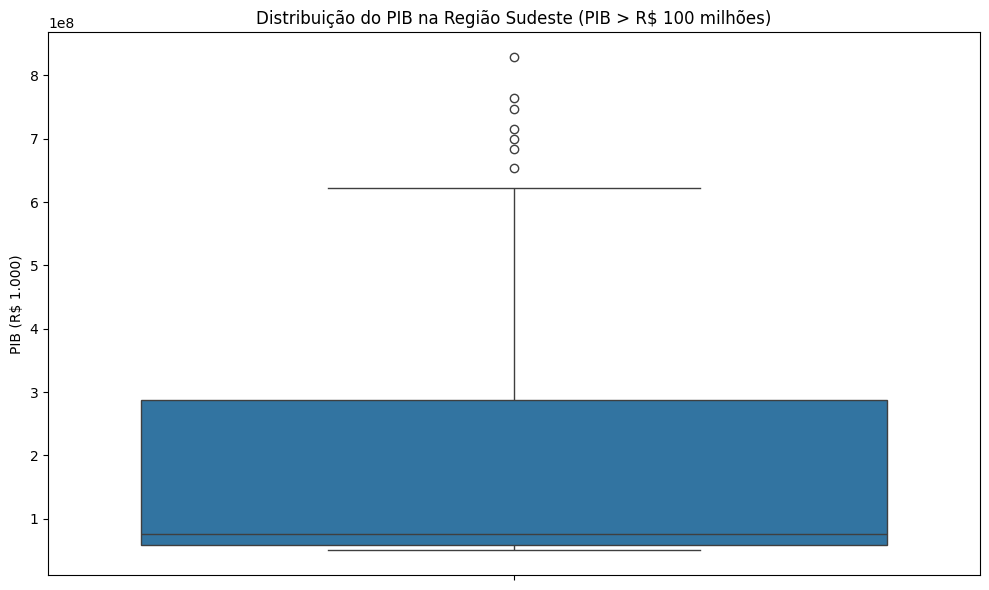

In [ ]:
pib_sudeste_filtered = municipios[(municipios['nm_grande_rg'] == 'Sudeste') & (municipios['pib_mil'] > 50000000)]

plt.figure(figsize=(10, 6))
sns.boxplot(y='pib_mil', data=pib_sudeste_filtered)
plt.title('Distribuição do PIB na Região Sudeste (PIB > R$ 100 milhões)')
plt.ylabel('PIB (R$ 1.000)')
plt.tight_layout()
plt.show()

In [ ]:
#Dados pnad
pnad = pd.read_excel('/content/tabela_pnad_continua.xlsx', sheet_name="Tabela", header=3, usecols="A:F")
pnad.head(50)

,Unnamed: 0,1º trimestre 2012,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,NaN,Total,Empregado,Empregador,Conta própria,Trabalhador familiar auxiliar
1,Brasil,87713,61908,3383,20096,2326
2,Norte,6462,3974,229,1887,372
3,Nordeste,21279,13387,637,6357,898
4,Sudeste,39167,29789,1500,7429,449
5,Sul,13907,9652,716,3028,510
6,Centro-Oeste,6898,5105,301,1394,97
7,Rondônia,695,440,24,193,37
8,Acre,284,188,9,72,15
9,Amazonas,1382,854,37,386,105


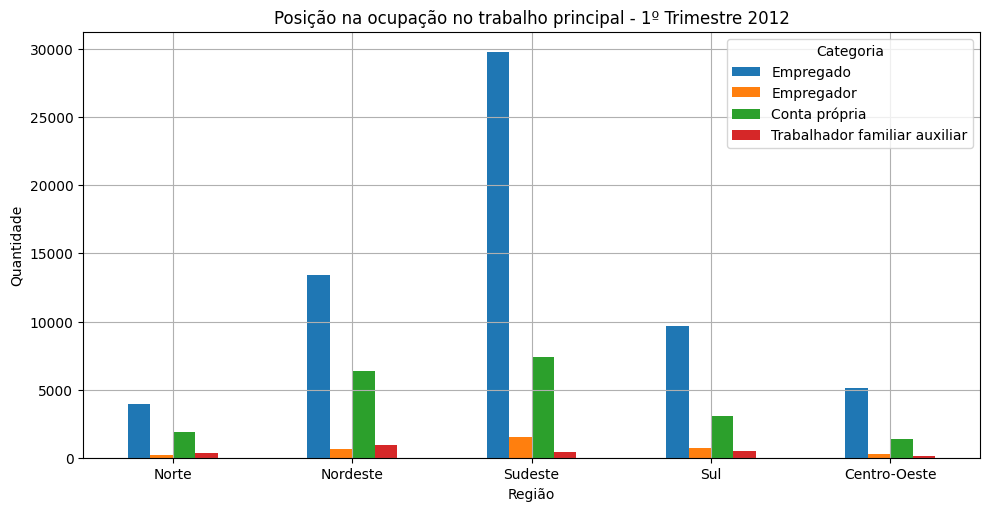

In [ ]:
# Renomear colunas
pnad.columns = ["Região", "Total", "Empregado", "Empregador", "Conta própria", "Trabalhador familiar auxiliar"]

# Remover linha de rótulos duplicados
pnad = pnad.drop(0)

# Selecionar apenas as grandes regiões (sin Brasil)
regioes = ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]
pnad = pnad[pnad["Região"].isin(regioes)]

# Converter valores para numéricos
pnad.iloc[:, 1:] = pnad.iloc[:, 1:].apply(pd.to_numeric, errors="coerce")

# Plotar gráfico de barras agrupadas
ax = pnad.set_index("Região").iloc[:, 1:].plot(kind="bar", figsize=(10, 6))

plt.title("Posição na ocupação no trabalho principal - 1º Trimestre 2012")
plt.ylabel("Quantidade")
plt.xlabel("Região")
plt.legend(title="Categoria")
plt.tight_layout()
plt.grid(True)
plt.xticks(rotation=0)
plt.show()

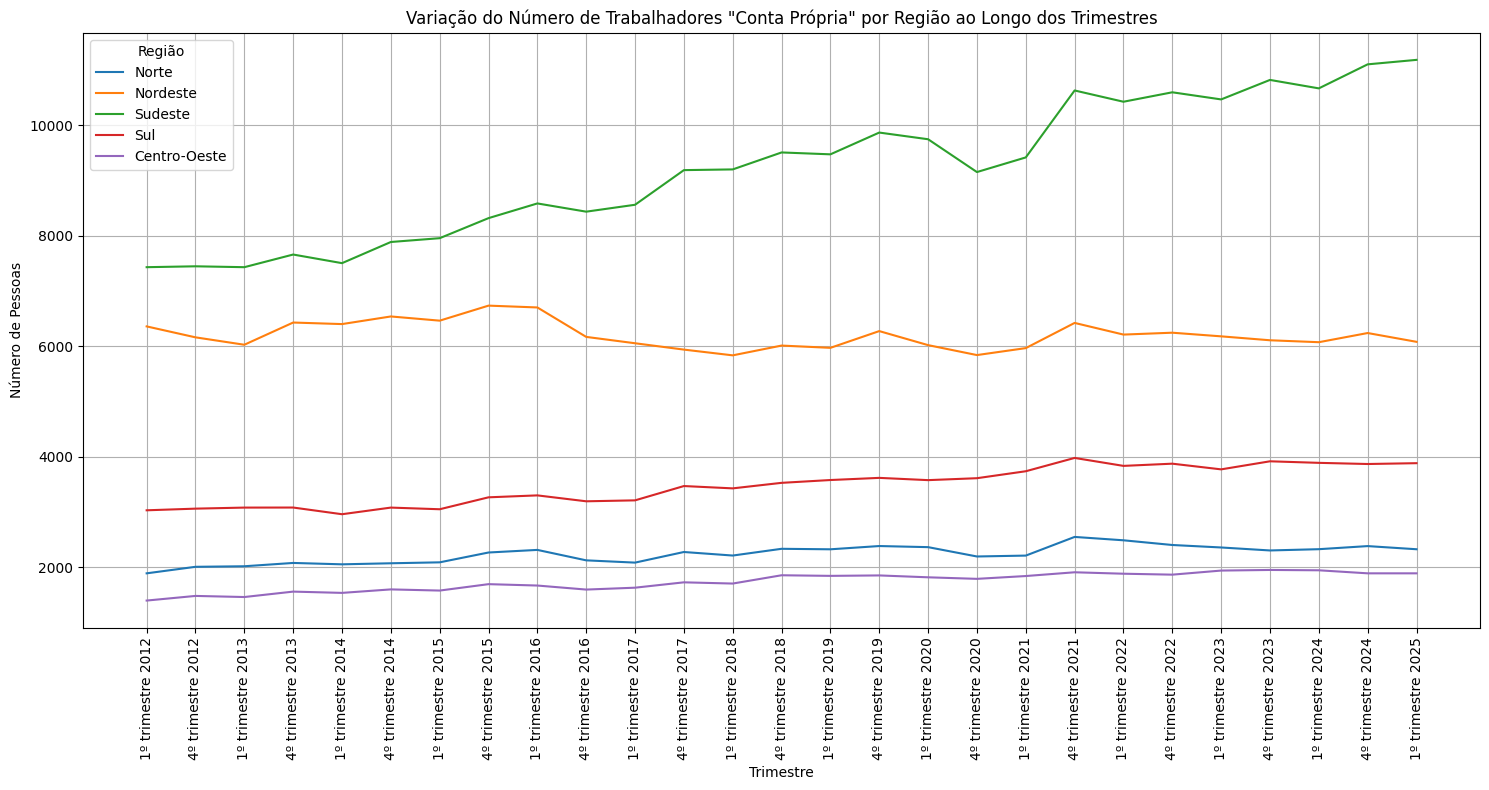

In [140]:

# Selecionar apenas as regiões desejadas
regioes = ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]
pnad = df[df["Unnamed: 0"].isin(regioes)].copy() # Usar 'Unnamed: 0' para filtrar e adicionar .copy() para evitar SettingWithCopyWarning

conta_propria_cols_indices = [0] + list(range(4, df.shape[1], 5)) # Coluna 0 para Região, e então cada 5ª coluna começando no índice 4. Usar df.shape[1] para ir até a última coluna dinamicamente.


# Selecionar apenas estas colunas
df_conta_propria = df.iloc[:, conta_propria_cols_indices].copy()

header_row = pd.read_excel(file_path, sheet_name="Tabela", header=2, nrows=1).iloc[0]

# Extrair os índices das colunas na header_row que correspondem ao *início* de cada bloco de trimestre (coluna Total)
quarter_header_indices = [i for i in range(1, len(header_row), 5)]

# Obter os nomes dos trimestres na linha do cabeçalho usando esses índices
quarter_names = [header_row.iloc[i] for i in quarter_header_indices if i < len(header_row)]

column_mapping = {df_conta_propria.columns[0]: 'Região'}
# Verificar se o número de colunas a serem renomeadas corresponde ao número de nomes de trimestre extraídos
if len(df_conta_propria.columns[1:]) == len(quarter_names):
    column_mapping.update(dict(zip(df_conta_propria.columns[1:], quarter_names)))
else:
    print("Aviso: O número de colunas a serem renomeadas não corresponde ao número de nomes de trimestre extraídos.")
    print("Colunas do DataFrame (excluindo Região):", df_conta_propria.columns[1:].tolist())
    print("Nomes de trimestre extraídos:", quarter_names)


df_conta_propria.rename(columns=column_mapping, inplace=True)

# Derreter o DataFrame para o formato longo (melt)
df_melted_quarters = df_conta_propria.melt(id_vars='Região', var_name='Trimestre', value_name='Número de Pessoas')

# Converter 'Número de Pessoas' para numérico
df_melted_quarters['Número de Pessoas'] = pd.to_numeric(df_melted_quarters['Número de Pessoas'], errors='coerce')

# Remover valores NaN
df_melted_quarters.dropna(inplace=True)

# Converter 'Trimestre' para um tipo categórico com categorias ordenadas para a ordem correta da plotagem
# Precisamos da lista completa dos nomes dos trimestres em ordem
full_header_row_quarters_names = pd.read_excel(file_path, sheet_name="Tabela", header=2, nrows=1).iloc[0, 1:]
# Extrair apenas os nomes dos trimestres que correspondem às colunas 'Total' (ou qualquer coluna consistente dentro de cada bloco de trimestre)
# Assumindo que a primeira coluna de cada bloco de trimestre (índice 1, 6, 11, etc.) contém o nome do trimestre na linha do cabeçalho 2.
full_quarter_names = [full_header_row_quarters_names.iloc[i] for i in range(0, len(full_header_row_quarters_names), 5)]


# Filtrar full_quarter_names para incluir apenas aqueles que estão na coluna 'Trimestre' de df_melted_quarters
present_quarter_names = df_melted_quarters['Trimestre'].unique().tolist()
ordered_quarter_names = [q for q in full_quarter_names if q in present_quarter_names]


df_melted_quarters['Trimestre'] = pd.Categorical(df_melted_quarters['Trimestre'], categories=ordered_quarter_names, ordered=True)

# Plotar os dados
plt.figure(figsize=(15, 8))
sns.lineplot(data=df_melted_quarters, x='Trimestre', y='Número de Pessoas', hue='Região')
plt.title('Variação do Número de Trabalhadores "Conta Própria" por Região ao Longo dos Trimestres')
plt.xlabel('Trimestre')
plt.ylabel('Número de Pessoas')
plt.xticks(rotation=90)
plt.tight_layout()
plt.grid(True)
plt.show()

,Região,Número de Conta Própria
0,Centro-Oeste,46825
1,Nordeste,167399
2,Norte,60356
3,Sudeste,248617
4,Sul,93806


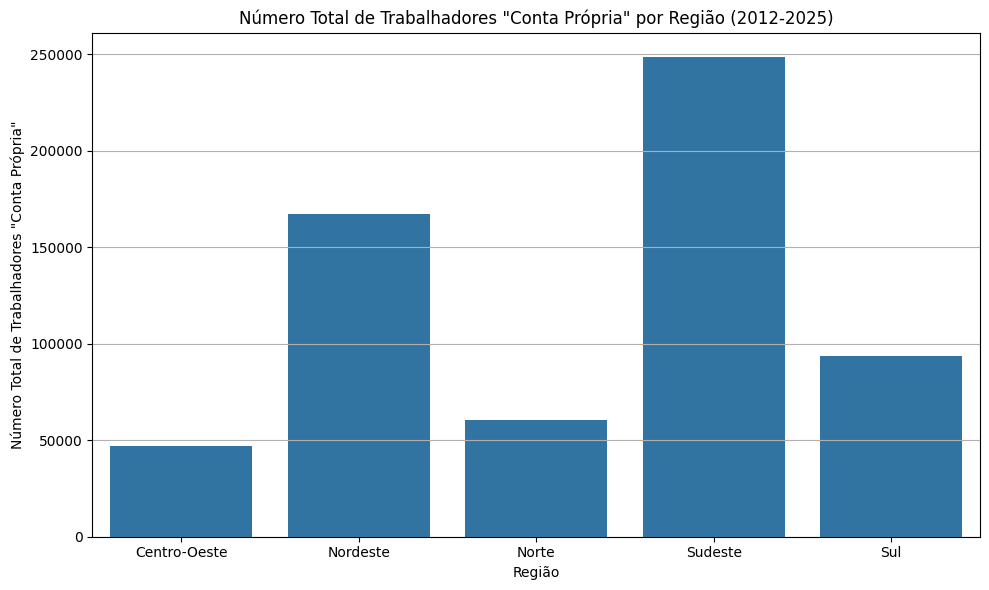

In [131]:
# Filter the pnad DataFrame to include only the main regions
regioes = ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]
pnad_filtered = pnad[pnad["Unnamed: 0"].isin(regioes)].copy()

# Extract the 'Conta própria' column for each quarter
conta_propria_cols_indices = [0] + list(range(4, pnad_filtered.shape[1], 5))
df_conta_propria = pnad_filtered.iloc[:, conta_propria_cols_indices].copy()

# Use the correct header row (index 2) for column names
header_row_pnad = pd.read_excel('/content/tabela_pnad_continua.xlsx', sheet_name="Tabela", header=2, nrows=1).iloc[0]

# Extract the quarter names from the header row corresponding to the 'Total' columns (which are at the beginning of each 5-column block)
quarter_header_indices_pnad = [i for i in range(1, len(header_row_pnad), 5)]
quarter_names_pnad = [header_row_pnad.iloc[i] for i in quarter_header_indices_pnad if i < len(header_row_pnad)]

# Create a dictionary to map the old column names to the new ones (Region + Quarter names)
column_mapping_pnad = {df_conta_propria.columns[0]: 'Região'}
if len(df_conta_propria.columns[1:]) == len(quarter_names_pnad):
    column_mapping_pnad.update(dict(zip(df_conta_propria.columns[1:], quarter_names_pnad)))
else:
    print("Warning: The number of columns to rename does not match the number of quarter names extracted.")
    print("DataFrame columns (excluding Região):", df_conta_propria.columns[1:].tolist())
    print("Extracted quarter names:", quarter_names_pnad)

df_conta_propria.rename(columns=column_mapping_pnad, inplace=True)

# Melt the DataFrame to long format
df_conta_propria_melted = df_conta_propria.melt(id_vars='Região', var_name='Trimestre', value_name='Número de Conta Própria')

# Convert 'Número de Conta Própria' to numeric
df_conta_propria_melted['Número de Conta Própria'] = pd.to_numeric(df_conta_propria_melted['Número de Conta Própria'], errors='coerce')

# Remove NaN values
df_conta_propria_melted.dropna(inplace=True)

# Group by Region and sum the number of self-employed workers
conta_propria_por_regiao = df_conta_propria_melted.groupby('Região')['Número de Conta Própria'].sum().reset_index()

# Display the result
display(conta_propria_por_regiao)

# Plotting the data
plt.figure(figsize=(10, 6))
sns.barplot(x='Região', y='Número de Conta Própria', data=conta_propria_por_regiao)
plt.title('Número Total de Trabalhadores "Conta Própria" por Região (2012-2025)')
plt.xlabel('Região')
plt.ylabel('Número Total de Trabalhadores "Conta Própria"')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

,Região,Número de Trabalhadores Familiares
0,Centro-Oeste,2484
1,Nordeste,18399
2,Norte,11134
3,Sudeste,12291
4,Sul,10855


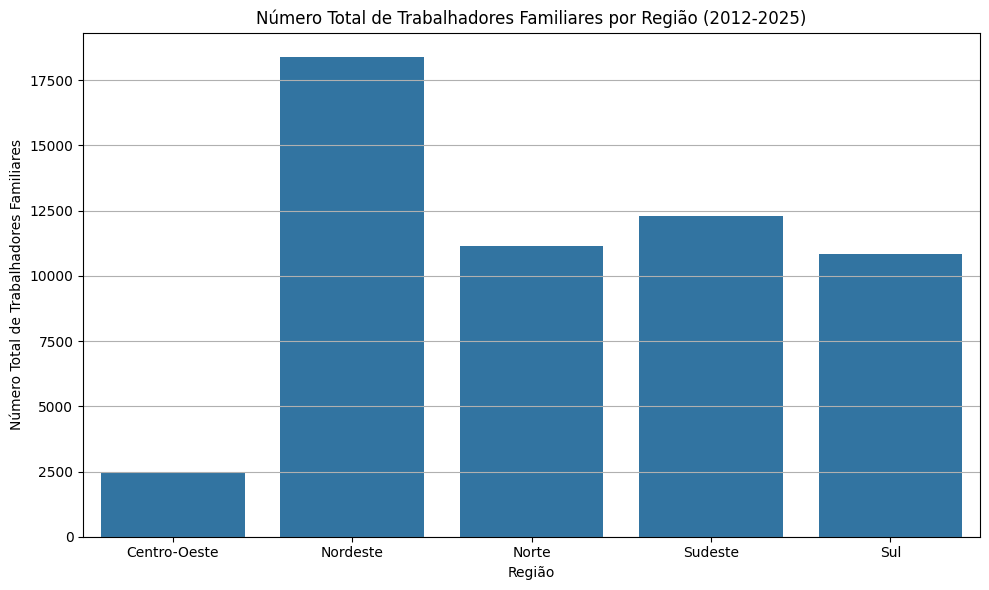

In [130]:
# Filter the pnad DataFrame to include only the main regions
regioes = ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]
pnad_filtered = pnad[pnad["Unnamed: 0"].isin(regioes)].copy()

# Extract the 'Trabalhador familiar auxiliar' column for each quarter
trabalhador_familiar_cols_indices = [0] + list(range(5, pnad_filtered.shape[1], 5))
df_trabalhador_familiar = pnad_filtered.iloc[:, trabalhador_familiar_cols_indices].copy()

# Use the correct header row (index 2) for column names
header_row_pnad = pd.read_excel('/content/tabela_pnad_continua.xlsx', sheet_name="Tabela", header=2, nrows=1).iloc[0]

# Extract the quarter names from the header row corresponding to the 'Total' columns (which are at the beginning of each 5-column block)
quarter_header_indices_pnad = [i for i in range(1, len(header_row_pnad), 5)]
quarter_names_pnad = [header_row_pnad.iloc[i] for i in quarter_header_indices_pnad if i < len(header_row_pnad)]

# Create a dictionary to map the old column names to the new ones (Region + Quarter names)
column_mapping_pnad = {df_trabalhador_familiar.columns[0]: 'Região'}
if len(df_trabalhador_familiar.columns[1:]) == len(quarter_names_pnad):
    column_mapping_pnad.update(dict(zip(df_trabalhador_familiar.columns[1:], quarter_names_pnad)))
else:
    print("Warning: The number of columns to rename does not match the number of quarter names extracted.")
    print("DataFrame columns (excluding Região):", df_trabalhador_familiar.columns[1:].tolist())
    print("Extracted quarter names:", quarter_names_pnad)

df_trabalhador_familiar.rename(columns=column_mapping_pnad, inplace=True)

# Melt the DataFrame to long format
df_trabalhador_familiar_melted = df_trabalhador_familiar.melt(id_vars='Região', var_name='Trimestre', value_name='Número de Trabalhadores Familiares')

# Convert 'Número de Trabalhadores Familiares' to numeric
df_trabalhador_familiar_melted['Número de Trabalhadores Familiares'] = pd.to_numeric(df_trabalhador_familiar_melted['Número de Trabalhadores Familiares'], errors='coerce')

# Remove NaN values
df_trabalhador_familiar_melted.dropna(inplace=True)


# Get the full ordered list of quarter names from the header
full_header_row_pnad_quarters_names = pd.read_excel('/content/tabela_pnad_continua.xlsx', sheet_name="Tabela", header=2, nrows=1).iloc[0, 1:]
full_quarter_names_pnad = [full_header_row_pnad_quarters_names.iloc[i] for i in range(0, len(full_header_row_pnad_quarters_names), 5)]

# Filter full_quarter_names_pnad to include only those present in the melted DataFrame
present_quarter_names_pnad = df_trabalhador_familiar_melted['Trimestre'].unique().tolist()
ordered_quarter_names_pnad = [q for q in full_quarter_names_pnad if q in present_quarter_names_pnad]


df_trabalhador_familiar_melted['Trimestre'] = pd.Categorical(df_trabalhador_familiar_melted['Trimestre'], categories=ordered_quarter_names_pnad, ordered=True)


# Group by Region and sum the number of family workers
trabalhador_familiar_por_regiao = df_trabalhador_familiar_melted.groupby('Região')['Número de Trabalhadores Familiares'].sum().reset_index()

# Display the result
display(trabalhador_familiar_por_regiao)

# Plotting the data
plt.figure(figsize=(10, 6))
sns.barplot(x='Região', y='Número de Trabalhadores Familiares', data=trabalhador_familiar_por_regiao)
plt.title('Número Total de Trabalhadores Familiares por Região (2012-2025)')
plt.xlabel('Região')
plt.ylabel('Número Total de Trabalhadores Familiares')
plt.grid(axis='y')
plt.tight_layout()
plt.show()